# Aplikativnost CMP

Cilj: Napisite celosten robotski program, ki iz zacetne lege najprej pobere rocko in jo premakne na koncno lego

1. Zajemite trajektorijo, ki pobere in odloži ročko.

2. Izvedite DMP togo (brez ročke) in narišite.

3. Izvedite DMP togo (z ročko) in narišite.

4. Zajemite navore brez ročke in izvedite CMP podajno in narišite.

5. Izvedite isti CMP z ročko ter narišite trajektorijo in napako.

6. Zajemite navore z ročko ter narišite trajektorijo in napako.

7. Spremenite gib s spremembo cilja trajektorije ter izvedite CMP.

8. Narišite trajektorijo in napako.

9. Primerjajte vse napake izvedbe in podajte zaključke glede CMP.

Skupaj z Andrejem in Mihom se dogovorite za samostojni seminar.

In [1]:
import rospy
import time
import numpy as np
from utils import pip
ns = "pingvin_1"
rospy.init_node(ns)
from robotblockset.ros.franka import panda_ros
r = panda_ros(ns=ns, control_strategy="JointImpedance", init_node=False)

Panda::Initialized
shutdown request: [/pingvin_1] Reason: new node registered with same name


In [69]:
from robotblockset.ros.grippers_ros import PandaGripper
g = PandaGripper(namespace=ns,robot=r)
r.SetGripper(g)

Panda:Gripper:ROS:Created


In [134]:
r.ErrorRecovery()

0

**1. Zajemite trajektorijo, ki pobere in odloži ročko.**

In [8]:
def record_robot_state(robot, frequency, duration):
    interval = 1.0 / frequency
    
    N=int(frequency*duration)
    tt = np.zeros((N,1))
    qt = np.zeros((N,r.nj))
    dqt = np.zeros((N,r.nj))

    i = 0
    start_time = time.monotonic()
    end_time = start_time + duration
    
    last_update = time.monotonic()

    while time.monotonic() <= end_time+interval and i < N:
        t = time.monotonic()
        if t - last_update >= interval:
            
            # Get robot state
            state = robot.GetState()
            
            tt[i] = t-start_time
            qt[i] = r.q
            dqt[i] = r.qdot

            # Update the last recorded time
            last_update = t
            i += 1
        
    return tt, qt, dqt, i, N    

Panda:Gripper:ROS:Created


In [71]:
r.SetJointCompliant() 

:Joint compliance changed 
Stiff:[ 0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000]
Damp:[ 0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000]


In [31]:
g.Close()

1

In [32]:
g.Open()

1

In [37]:
time.sleep(1)
print ("start")
tt, qt, dqt, i, N = record_robot_state(r,100,6)
print ("stop")

start
stop


**2. Izvedite DMP togo (brez ročke) in narišite.**

In [124]:
import utils
from utils import SoftSetJointCompliance
r.ResetCurrentTarget()
SoftSetJointCompliance(r,r._franka_default.JointCompliance.K,4)

:Joint compliance changed 
Stiff:[ 1200.0000  1200.0000  1200.0000  1200.0000  0.0000  0.0000  0.0000]
Damp:[25 25 25 25 10 10 10]


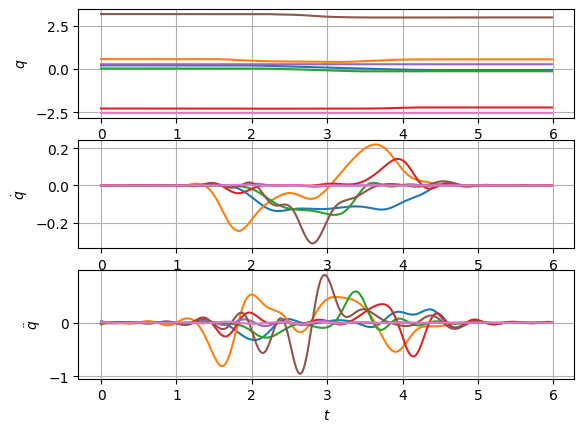

In [40]:
from dmp import DMP
from robotblockset.graphics import plotjtraj
import matplotlib.pyplot as plt

d = DMP(qt.copy(),np.squeeze(tt.copy()),vel_data=dqt.copy(),num_weights=25)
trj_dec,t_dec=d.decode()
plotjtraj(qt=trj_dec, t=t_dec);

In [52]:
r.JMove(qt[0],5)
napaka1=[]
navori1=[]
N=np.size(qt,0)
for q, qdot, tm in zip(qt, dqt, np.diff(tt, axis=0)): 
    # Call the GoTo_q function
    navori1.append(r.state.tau_J_d)
    r.GoTo_q(q,np.zeros(7),np.zeros(7),0)
    q_d=r.q
    napaka1.append(np.linalg.norm(q-q_d))
    
    # time.sleep(1/100.)
    time.sleep(tm[0])

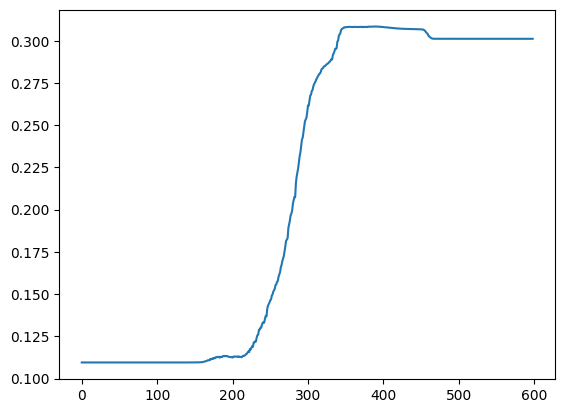

In [53]:
plt.plot(napaka1);


**3. Izvedite DMP togo (z ročko) in narišite.**


In [42]:
r.JMove(qt[0],5)

0

In [54]:
r.JMove(qt[0],5)
napaka2=[]
navori2=[]
N=np.size(qt,0)
g.Close()
for q, qdot, tm in zip(qt, dqt, np.diff(tt, axis=0)): 
    # Call the GoTo_q function
    navori2.append(r.state.tau_J_d)
    r.GoTo_q(q,np.zeros(7),np.zeros(7),0)
    q_d=r.q
    napaka2.append(np.linalg.norm(q-q_d))
    
    # time.sleep(1/100.)
    time.sleep(tm[0])
g.Open()

1

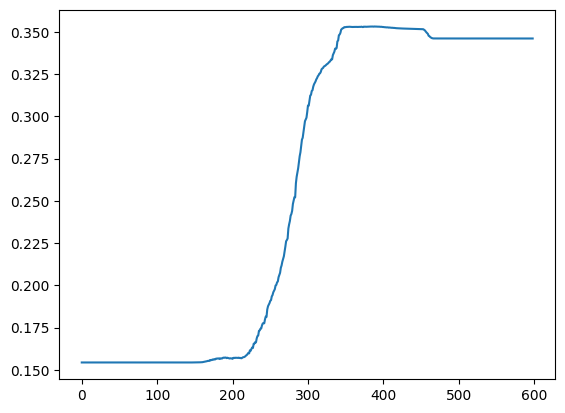

In [55]:
plt.plot(napaka2);


**4. Zajemite navore brez ročke in izvedite CMP podajno in narišite.**


In [121]:
r.SetStrategy("JointImpedance")
r.SetJointCompliant() 

:Shutting down controller interface: cartesian_impedance_controller
:Joint compliance changed 
Stiff:[ 0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000]
Damp:[ 0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000]


In [122]:
def record_robot_cartesian(robot, frequency, duration):
    interval = 1.0 / frequency
    N = int(frequency * duration)

    tt = np.zeros(N)
    xt = np.zeros((N, 7))
    dxt = np.zeros((N, 7))

    i = 0
    start_time = time.monotonic()
    end_time = start_time + duration
    last_update = start_time - interval

    while time.monotonic() <= end_time and i < N:
        t = time.monotonic()
        if t - last_update >= interval:
            pos = robot.x.copy()
            tt[i] = t - start_time
            xt[i, :] = pos

            if i > 0:
                dxt[i, :] = (xt[i, :] - xt[i-1, :]) / interval

            last_update = t
            i += 1

    return tt, xt, dxt, i, N

In [123]:
time.sleep(1)
print ("start")
tt, xt, dxt, i, N = record_robot_cartesian(r,100,6)
print ("stop")

start
stop


In [60]:
r.ResetCurrentTarget()
r.SetJointSoft(0.1)

:Joint compliance changed 
Stiff:[120. 120. 120. 120.  25.  25.  10.]
Damp:[2.5 2.5 2.5 2.5 1.  1.  1. ]


In [89]:
import inspect
sig = inspect.signature(r.GoTo_X)
print(sig)

(x, xdot, trq, wait, do_not_publish_msg=False, **kwargs)


In [116]:
r.ErrorRecovery()

Panda::Recovering from errors:
 ['communication_constraints_violation']
Panda::Attempting to change robot mode from 4


0

In [125]:
r.CMove(xt[0], 5)

0

In [126]:
r.SetStrategy("CartesianImpedance")


:Shutting down controller interface: joint_impedance_controller


In [127]:
napaka3 = []
navori3 = []

for x, xdot, tm in zip(xt, dxt, np.diff(tt)):
    navori3.append(r.state.tau_J_d)

    xdot1 = xdot[:-1].copy()
    xdot1[3:] = 0
    print(xdot1)

    r.GoTo_X(x=x, xdot=xdot1, trq=np.zeros(6), wait=0)
    x_d = r.x
    napaka3.append(np.linalg.norm(x - x_d))

    time.sleep(tm)

[ 0.0000  0.0000  0.0000  0.0000  0.0000  0.0000]
[-0.0001 -0.0002  0.0004  0.0000  0.0000  0.0000]
[-0.0001 -0.0001 -0.0002  0.0000  0.0000  0.0000]
[ 0.0000 -0.0000 -0.0000  0.0000  0.0000  0.0000]
[ 0.0001  0.0001  0.0001  0.0000  0.0000  0.0000]
[-0.0002 -0.0001 -0.0005  0.0000  0.0000  0.0000]
[ 0.0001 -0.0001  0.0002  0.0000  0.0000  0.0000]
[ 0.0000  0.0000  0.0000  0.0000  0.0000  0.0000]
[ 0.0001  0.0003  0.0001  0.0000  0.0000  0.0000]
[ 0.0001  0.0000  0.0002  0.0000  0.0000  0.0000]
[-0.0002 -0.0001 -0.0003  0.0000  0.0000  0.0000]
[-0.0001 -0.0001 -0.0000  0.0000  0.0000  0.0000]
[ 0.0003  0.0003 -0.0002  0.0000  0.0000  0.0000]
[-0.0001 -0.0002  0.0005  0.0000  0.0000  0.0000]
[ 0.0000  0.0001 -0.0001  0.0000  0.0000  0.0000]
[-0.0001 -0.0004 -0.0003  0.0000  0.0000  0.0000]
[-0.0001 -0.0002 -0.0001  0.0000  0.0000  0.0000]
[ 0.0001  0.0004  0.0003  0.0000  0.0000  0.0000]
[ 0.0001 -0.0002  0.0001  0.0000  0.0000  0.0000]
[-0.0000  0.0004 -0.0002  0.0000  0.0000  0.0000]


In [135]:
r.SetStrategy("JointImpedance")

Panda::Not switching because already using 'JointImpedance'


False

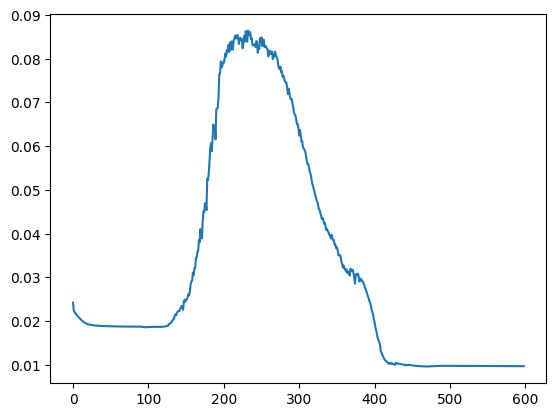

In [129]:
plt.plot(napaka3);

**5. Izvedite isti CMP z ročko ter narišite trajektorijo in napako.**


In [ ]:
r.SetStrategy("JointImpedance")

In [136]:
r.CMove(xt[0], 5)

0

In [137]:
r.SetStrategy("CartesianImpedance")


:Shutting down controller interface: joint_impedance_controller


In [ ]:
napaka4 = []
navori4 = []
g.Close()
for x, xdot, tm in zip(xt, dxt, np.diff(tt)):
    navori4.append(r.state.tau_J_d)

    xdot1 = xdot[:-1].copy()
    xdot1[3:] = 0
    print(xdot1)

    r.GoTo_X(x=x, xdot=xdot1, trq=np.zeros(6), wait=0)
    x_d = r.x
    napaka4.append(np.linalg.norm(x - x_d))

    time.sleep(tm)
g.Open()

**6. Zajemite navore z ročko ter narišite trajektorijo in napako.**


**7. Spremenite gib s spremembo cilja trajektorije ter izvedite CMP.**


**8. Narišite trajektorijo in napako.**


**9. Primerjajte vse napake izvedbe in podajte zaključke glede CMP.**